# Simple Neural Network from scratch in MNIST dataset

This is a project that tries to implement a simple neural network using only basic python and simple mathematical tools

## 1. Importing Dataset and Data Handling
Import, explore and visualize the dataset using keras for simplicity

In [4]:
import numpy as np
import matplotlib.pyplot as plt

Percentage of train data: 0.86
Percentage of val data: 0.07
Percentage of test data: 0.07


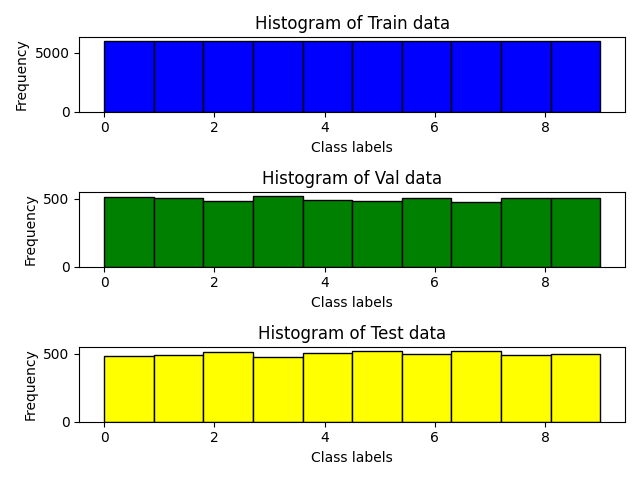


Normalize input values:
Min value of input:  0
Max value of input:  255
Min value of normalized input:  0.0
Max value of normalized input:  1.0
X_train: (60000, 784)
Y_train: (60000, 10)
X_val: (5000, 784)
Y_val: (5000, 10)
X_test: (5000, 784)
Y_test: (5000, 10)


In [30]:
from keras.datasets import fashion_mnist as mnist
from sklearn.model_selection import train_test_split

# Load dataset
(x_2d_train, y_train), (x_2d_test, y_test) = mnist.load_data()


# Flatten the 2D images to 1D vectors
x_train = x_2d_train.reshape(x_2d_train.shape[0], -1)
x_test = x_2d_test.reshape(x_2d_test.shape[0], -1)


# Split test data to test and validation data respectively
x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size=0.5, random_state=42)

percentage_train = len(y_train) / float(len(y_train) + len(y_val) + len(y_test))
percentage_val = len(y_val) / float(len(y_train) + len(y_val) + len(y_test))
percentage_test = len(y_test) / float(len(y_train) + len(y_val) + len(y_test))


print(f"Percentage of train data: {percentage_train:.2f}")
print(f"Percentage of val data: {percentage_val:.2f}")
print(f"Percentage of test data: {percentage_test:.2f}")


# Histogram of number distributions on each data subdivision
fig, ax = plt.subplots(3,1)

ax[0].hist(y_train, color='Blue', edgecolor='black')
ax[0].set_title("Histogram of Train data")
ax[0].set_ylabel("Frequency")
ax[0].set_xlabel("Class labels")


ax[1].hist(y_val, color='Green', edgecolor='black')
ax[1].set_title("Histogram of Val data")
ax[1].set_ylabel("Frequency")
ax[1].set_xlabel("Class labels")

ax[2].hist(y_test, color='Yellow', edgecolor='black')
ax[2].set_title("Histogram of Test data")
ax[2].set_ylabel("Frequency")
ax[2].set_xlabel("Class labels")

plt.tight_layout()
plt.show()

# Implement stratified sampling






# Normalize input values
print('\nNormalize input values:')
def normalize(numbers, new_min=0.0, new_max=1.0):
    curr_min = float(numbers.min())
    curr_max = float(numbers.max())

    normalized = (numbers-curr_min)/(curr_max-curr_min)

    return normalized

print('Min value of input: ',x_train.min())
print('Max value of input: ',x_train.max())
x_train = normalize(x_train)
x_test = normalize(x_test)
x_val = normalize(x_val)
print('Min value of normalized input: ',x_train.min())
print('Max value of normalized input: ',x_train.max())

# Convert target data to one hot encoding vectors
def toonehot(input):
    temp = np.zeros((input.shape[0], 10))
    for i, row in enumerate(input):
        temp[i][input[i]] = 1

    return temp

y_train = toonehot(y_train)
y_val = toonehot(y_val)
y_test = toonehot(y_test)

print("X_train:", x_train.shape)
print("Y_train:", y_train.shape)
print("X_val:", x_val.shape)
print("Y_val:", y_val.shape)
print("X_test:", x_test.shape)
print("Y_test:", y_test.shape)


### 1.1 Visualize the dataset

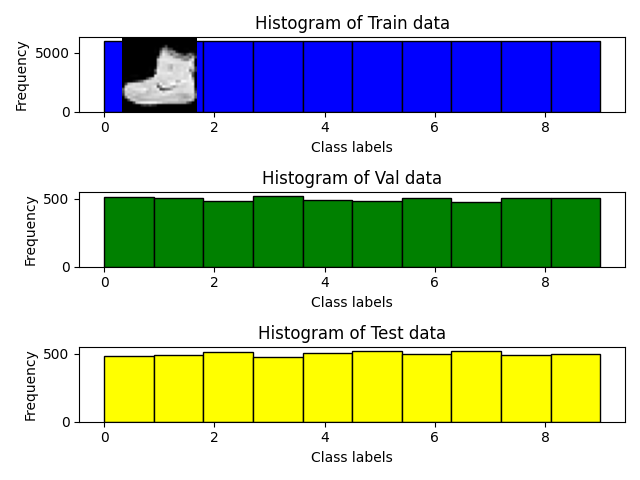

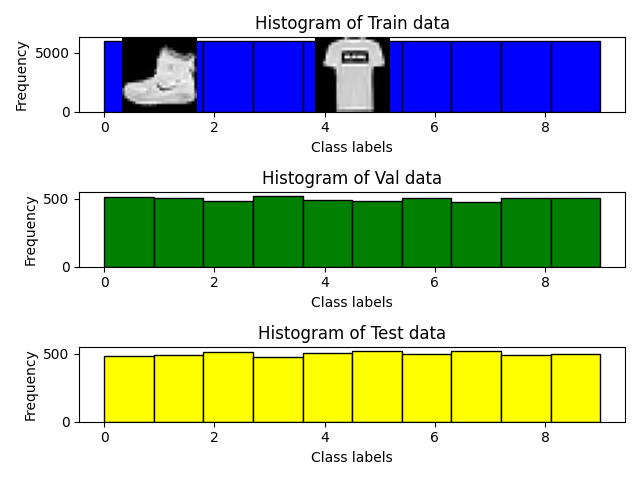

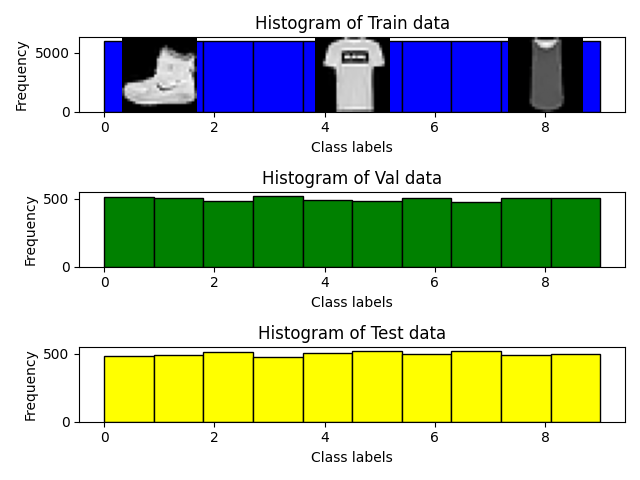

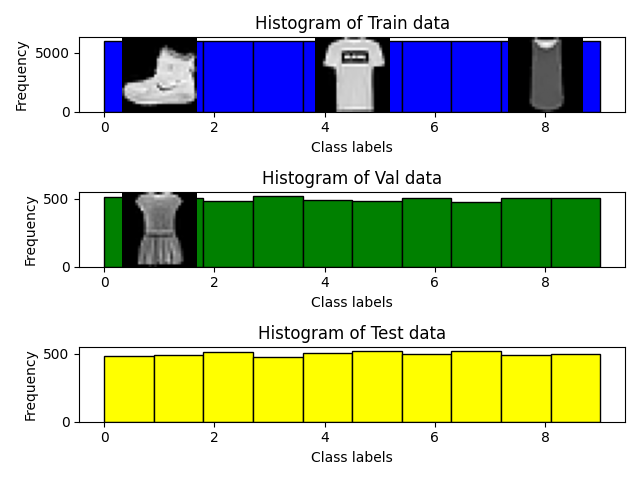

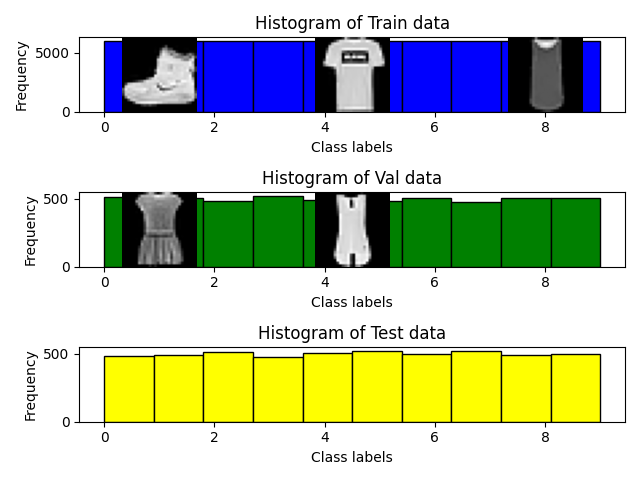

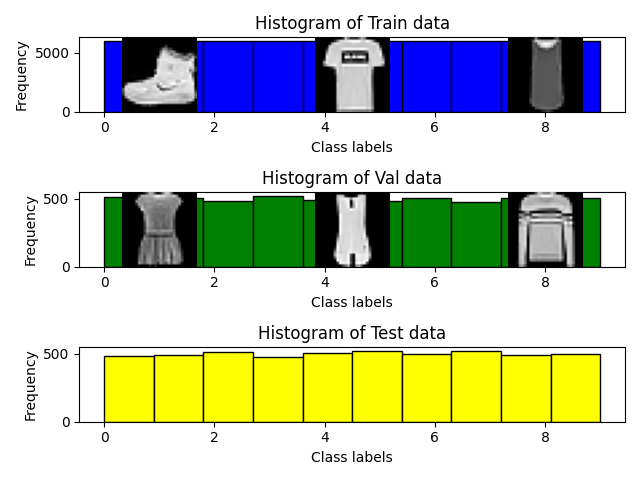

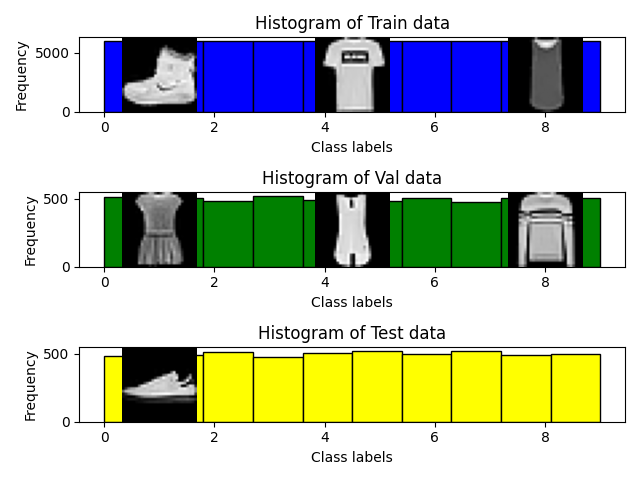

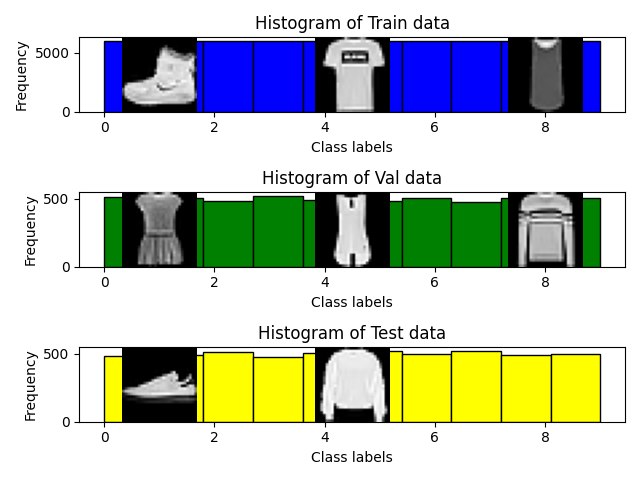

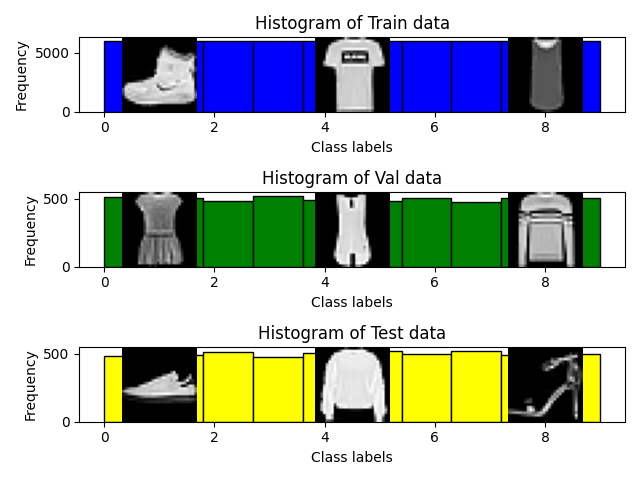

In [ ]:
def visualize_image(image):
    plt.imshow(image, cmap=plt.get_cmap('gray'))
    plt.axis('off')
    plt.show()

for i in range(9):
    plt.subplot(330 + 1 + i)
    # plt.imshow(x_2d_train[i], cmap=plt.get_cmap('gray'))
    # plt.show()
    visualize_image(x_2d_train[i])


### 2. Class init

In [16]:
class Neural_Net:
    def __init__(self, layer_sizes, activations, epochs=10, batch_size=32, learning_rate=0.01):
        self.epochs = epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate

        self.layer_sizes = layer_sizes
        self.activations = activations

        self.layers = []
        # Build the layers of the neural network
        for i in range(len(layer_sizes) - 1):
            is_output = (i == len(layer_sizes) - 2)

            self.layers.append(
                Layer(
                    layer_sizes[i], 
                    layer_sizes[i+1], 
                    activations[i],
                    output_layer=is_output
                )
            )

        for i in range(len(self.layers) - 1):
            self.layers[i].next_layer = self.layers[i+1]

        self.loss = []
        self.accuracies = []
        self.loss_per_epoch = []



    def fit(self, x_train, y_train, x_val=None, y_val=None, Verbose=True):
        L = 0
        for epoch in range(self.epochs):
            if Verbose:
                print(f"Epoch {epoch+1}/{self.epochs}")

            perm = np.random.permutation(len(x_train))
            x_train_shuffled = x_train[perm]
            y_train_shuffled = y_train[perm]

            # Run across the entire training data in batches
            for j in range(x_train_shuffled.shape[0] ):
                x = x_train_shuffled[j]
                targets = y_train_shuffled[j]

                outputs = self._forward(x)
                self._backward(targets)

                # Update weights (once every mini batch)
                L += (1/mini_batch) * cross_entropy_loss(outputs, targets)
                if (j+1)%mini_batch == 0:
                    self.loss.append(L)

                    L = 0

                    self._update_weights()

            if x_val is not None and y_val is not None:
                accuracy = self.evaluate(x_val, y_val)
                self.accuracies.append(accuracy)
                self.loss_per_epoch.append(self.loss[-1])

                if Verbose:
                    print(f"Loss for epoch {epoch+1}: {self.loss[-1]:.4f}")
                    print(f"Validation accuracy for epoch {epoch+1}: {accuracy:.4f}")

        return self.loss_per_epoch, self.accuracies

    def predict(self, x):
        outputs = self._forward(x)
        return np.argmax(outputs)

    def evaluate(self, x_val, y_val):
        correct_predictions = sum( self.predict(x_val[i]) == np.argmax(y_val[i]) for i in range(len(x_val)))
        accuracy = correct_predictions / len(x_val)
        return accuracy

    def _forward(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def _backward(self, targets):
        for layer in reversed(self.layers):
            layer.backward(mini_batch=self.batch_size, targets=targets)
            

    def _update_weights(self):
        for layer in self.layers:
            layer.update_weights(self.learning_rate)

In [8]:
class relu:
    def forward(self, z):
        return np.maximum(0,z)
    
    def derivative(self, output):
        return 1 * (output>0)
    
class leaky_relu:
    def __init__(self, alpha=0.01):
        self.alpha = alpha
        
    def forward(self, z):
        return np.where(z > 0, z, self.alpha * z)
    
    def derivative(self, output):
        return np.where(output > 0, 1, self.alpha)
    

class softmax:
    def forward(self, z):
        z_shifted = z - max(z)
        exped = np.exp(z_shifted)
        return exped / np.sum(exped)
    
    def derivative(self, output):
        pass

def cross_entropy_loss(predictions, targets):
    loss = -np.sum(targets * np.log(predictions + 1e-12) )
    return loss

In [ ]:
class Layer:
    def __init__(self, input_size, output_size, activation_func=relu(), output_layer=False):
        self.input_size = input_size
        self.output_size = output_size
        # self.weights = np.random.rand(output_size, input_size) * 0.001
        self.weights = np.random.randn(output_size, input_size) * np.sqrt(2 / input_size)
        self.new_weights = None # maybe not necessary
        self.biases = np.zeros(output_size) #np.random.rand(output_size)
        self.new_biases = None # maybe not necessary

        self.inputs = None

        self.z = None
        self.a = None

        self.activation_func = activation_func

        self.delta = None
        self.grad_w = 0
        self.grad_b = 0

        self.output_layer = output_layer

        self.next_layer = None

    def forward(self, inputs):
        # z = W*x + b
        self.inputs = inputs
        self.z = np.dot(self.weights, self.inputs)
        self.z += self.biases
        
        # a = g(z)
        self.a = self.activation_func.forward(self.z)
        return self.a
    
    def backward(self, mini_batch=32, targets=None):
        
        # Calculate delta
        if self.output_layer:
            self.delta = self.a - targets
        else:
            next_w = self.next_layer.weights
            next_delta = self.next_layer.delta
            # (next weights (not updated) @ next delta) * self.activation_func.derivative()
            self.delta = np.dot(next_w.T, next_delta) * self.activation_func.derivative(self.z) 

        # Calculate gradients 
        self.grad_w += (1/mini_batch) * np.outer(self.delta, self.inputs)
        self.grad_b += (1/mini_batch) * self.delta

    def update_weights(self, learning_rate):
        # W' = W - η*ΔW
        # print('grad w:', self.grad_w.shape)
        # print('grad b:', self.grad_b.shape)
        self.weights -= learning_rate * self.grad_w
        self.biases -= learning_rate * self.grad_b

        self.grad_w = 0
        self.grad_b = 0
        







        
    

In [ ]:
model = Neural_Net(layer_sizes=[784, 128, 32, 10], activations=[leaky_relu(), leaky_relu(), softmax()], epochs=10, batch_size=64, learning_rate=0.005)

losses, accuracies = model.fit(x_train, y_train, x_val=x_val, y_val=y_val, Verbose=True)
losses, accuracies = [float(loss) for loss in losses], [float(acc) for acc in accuracies]

Epoch 1/10
Loss for epoch 1: 0.7932
Validation accuracy for epoch 1: 0.7402
Epoch 2/10
Loss for epoch 2: 0.5589
Validation accuracy for epoch 2: 0.7876
Epoch 3/10
Loss for epoch 3: 0.4680
Validation accuracy for epoch 3: 0.8066
Epoch 4/10
Loss for epoch 4: 0.6248
Validation accuracy for epoch 4: 0.8144
Epoch 5/10
Loss for epoch 5: 0.5511
Validation accuracy for epoch 5: 0.8110
Epoch 6/10
Loss for epoch 6: 0.3581
Validation accuracy for epoch 6: 0.8228
Epoch 7/10
Loss for epoch 7: 0.3411
Validation accuracy for epoch 7: 0.8292
Epoch 8/10
Loss for epoch 8: 0.5612
Validation accuracy for epoch 8: 0.8302
Epoch 9/10
Loss for epoch 9: 0.3341
Validation accuracy for epoch 9: 0.8320
Epoch 10/10
Loss for epoch 10: 0.7570
Validation accuracy for epoch 10: 0.8366


([np.float64(0.7932074164277432),
  np.float64(0.5588564224369859),
  np.float64(0.4679687130095828),
  np.float64(0.6247753444564755),
  np.float64(0.5510945449493053),
  np.float64(0.35807265454103016),
  np.float64(0.3410992989251148),
  np.float64(0.5611767829884922),
  np.float64(0.33410274748043944),
  np.float64(0.7569642632648433)],
 [np.float64(0.7402),
  np.float64(0.7876),
  np.float64(0.8066),
  np.float64(0.8144),
  np.float64(0.811),
  np.float64(0.8228),
  np.float64(0.8292),
  np.float64(0.8302),
  np.float64(0.832),
  np.float64(0.8366)])

## 3.1 Testing the model in Test set

It's important to test model's performance in unseen data, this way we are unbiased.

In [29]:
accuracy = float(model.evaluate(x_test, y_test))

print(f"Test accuracy: {accuracy:.2%}")

Test accuracy: 83.44%


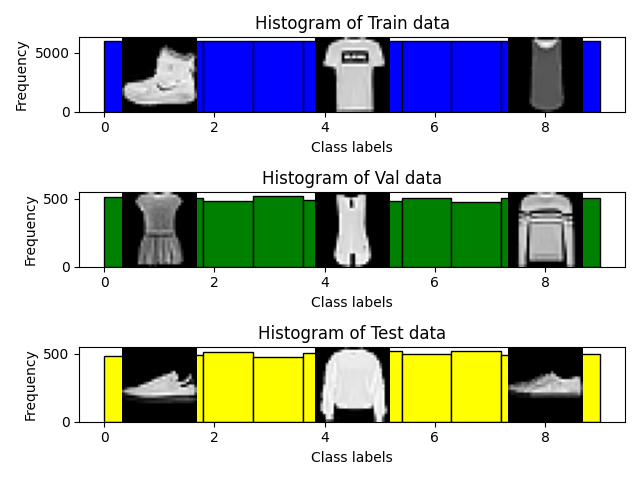

In [32]:
random_index = np.random.randint(0, len(x_test))
random_image = x_test[random_index]

visualize_image(random_image.reshape(28,28))